# Function 3 - Noise-aware exploitative optimisation (Week 10)

This week we changed Function 3 so it is structured like the Week 10 notebooks for Functions 4 and 6: the notebook now focuses on **optimisation**, not on re-run comparison.

## What changed this week and why

- We removed the comparison / re-run workflow from this notebook so the logic is simpler and matches the optimisation-only structure used for Functions 4 and 6.
- We created a **new noise-aware exploitative BO model** for Function 3. It keeps a `WhiteKernel` because Function 3 still looks noisy, but it now defaults to **beta = 0.0** so the search focuses on maximising the GP mean around the current best region.
- The goal this week is to **refine around the strong region found in Weeks 8-9**, rather than spend the whole notebook analysing whether earlier points were noisy.

So the strategy this week is: use the same clear validation flow as Functions 4 and 6, but keep a noise-aware surrogate because Function 3 is still the noisy one.

In [8]:
import json
import importlib
import sys
from pathlib import Path

import numpy as np

sys.path.append('../..')  # Go up two levels to project root

import scripts.utils.data_utils as data_utils
importlib.reload(data_utils)

from scripts.bayesian_optimisation.bayesian_optimization_noise_exploitative import NoiseAwareExploitativeBayesianOptimization
from scripts.utils.data_utils import (
    _load_latest_week_data,
    load_initial_data,
    load_week1_data,
    load_week2_data,
    load_week3_data,
    load_week4_data,
    plot_3d_scatter_with_distribution,
)


In [9]:
base_dir = Path('../../data/initial_data')
week1_dir = Path('../../data/week1')
week2_dir = Path('../../data/week2')
week3_dir = Path('../../data/week3')
week4_dir = Path('../../data/week4')
week5_dir = Path('../../data/week5')
week6_dir = Path('../../data/week6')
week7_dir = Path('../../data/week7')
week8_dir = Path('../../data/week8')
week9_dir = Path('../../data/week9')

initial_data = load_initial_data(base_dir)
week1_data = load_week1_data(week1_dir)
week2_data = load_week2_data(week2_dir)
week3_data = load_week3_data(week3_dir)
week4_data = load_week4_data(week4_dir)
week5_data = _load_latest_week_data(week5_dir, 'Week 5')
week6_data = _load_latest_week_data(week6_dir, 'Week 6')
week7_data = _load_latest_week_data(week7_dir, 'Week 7')
week8_data = _load_latest_week_data(week8_dir, 'Week 8')
week9_data = _load_latest_week_data(week9_dir, 'Week 9')

print(f'Loaded initial data for {len(initial_data)} functions')
print(f"Loaded through Week 9. Latest Function 3 output: {week9_data['function_3']['output']}")


Loaded initial data for 8 functions
Loaded through Week 9. Latest Function 3 output: -0.005773168171416292


In [10]:
def validate_progress(y_observed, function_name=None, recent_k=3, tol_frac=0.01, min_improve_frac=0.05):
    """
    Deterministic progress check for maximizing an objective (higher is better).
    Uses safe magnitude-based tolerances so it also behaves sensibly when
    most values are negative, as in Function 3.
    """
    y = np.asarray(y_observed, dtype=float)
    n = len(y)

    if n < recent_k + 1:
        return 'insufficient_data', 'Not enough data to validate', False

    recent = y[-recent_k:]
    best_overall = float(np.max(y))
    best_recent = float(np.max(recent))

    scale = max(abs(best_overall), 1e-12)
    close_tol = tol_frac * scale
    near_best = (best_overall - best_recent) <= close_tol

    prev = float(y[-2])
    last = float(y[-1])
    step_scale = max(abs(prev), 1e-12)
    step_improve_frac = (last - prev) / step_scale

    if near_best:
        if step_improve_frac >= min_improve_frac:
            return 'improving', f'Near best and still improving. Best={best_overall:.6f}, last={last:.6f}', False
        return 'plateau', f'Near best but improvements are small. Best={best_overall:.6f}, last={last:.6f}', True

    recent_trend = float(recent[-1] - recent[0])
    if recent_trend > 0:
        return 'improving', f'Recent trend is positive, moving toward best={best_overall:.6f}', False
    return 'stuck', f'Recent trend is negative and not near best. Best={best_overall:.6f}, recent_best={best_recent:.6f}', True


FUNCTION 3 - COMBINED DATA & VALIDATION
Combined inputs shape: (24, 3)
Combined outputs shape: (24,)
Best observed output so far: -0.005533
Incumbent input: [0.627294 0.574073 0.51083 ]
Mean output: -0.120363
Std output: 0.103822

WARNING PROGRESS STATUS: PLATEAU
  Near best but improvements are small. Best=-0.005533, last=-0.005773


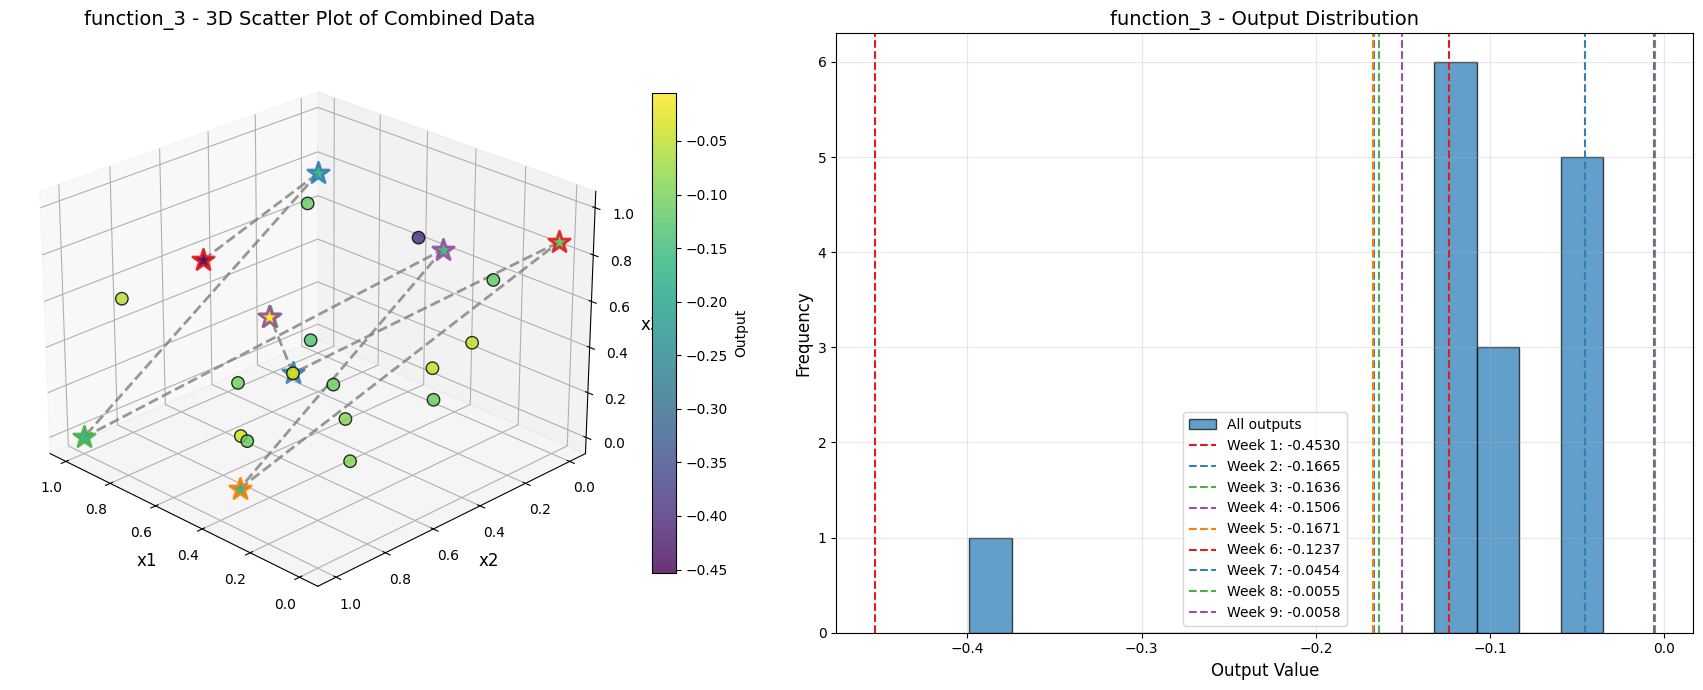

In [11]:
function_name = 'function_3'

original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']
week4_input = week4_data[function_name]['input']
week4_output = week4_data[function_name]['output']
week5_input = week5_data[function_name]['input']
week5_output = week5_data[function_name]['output']
week6_input = week6_data[function_name]['input']
week6_output = week6_data[function_name]['output']
week7_input = week7_data[function_name]['input']
week7_output = week7_data[function_name]['output']
week8_input = week8_data[function_name]['input']
week8_output = week8_data[function_name]['output']
week9_input = week9_data[function_name]['input']
week9_output = week9_data[function_name]['output']

X_observed = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1),
    week4_input.reshape(1, -1),
    week5_input.reshape(1, -1),
    week6_input.reshape(1, -1),
    week7_input.reshape(1, -1),
    week8_input.reshape(1, -1),
    week9_input.reshape(1, -1),
])
y_observed = np.concatenate([
    original_outputs,
    np.array([
        week1_output,
        week2_output,
        week3_output,
        week4_output,
        week5_output,
        week6_output,
        week7_output,
        week8_output,
        week9_output,
    ]),
])

status, message, flag = validate_progress(y_observed, function_name)
incumbent_idx = int(np.argmax(y_observed))
incumbent_input = X_observed[incumbent_idx]
incumbent_output = float(y_observed[incumbent_idx])

print('=' * 60)
print('FUNCTION 3 - COMBINED DATA & VALIDATION')
print('=' * 60)
print(f'Combined inputs shape: {X_observed.shape}')
print(f'Combined outputs shape: {y_observed.shape}')
print(f'Best observed output so far: {incumbent_output:.6f}')
print(f'Incumbent input: {incumbent_input}')
print(f'Mean output: {y_observed.mean():.6f}')
print(f'Std output: {y_observed.std():.6f}')
print(f"\n{'WARNING ' if flag else 'OK '}PROGRESS STATUS: {status.upper()}")
print(f'  {message}')
print('=' * 60)

plot_3d_scatter_with_distribution(
    original_inputs,
    original_outputs,
    week9_input,
    week9_output,
    function_name,
    weekly_points=[
        (week1_input, week1_output, 'Week 1'),
        (week2_input, week2_output, 'Week 2'),
        (week3_input, week3_output, 'Week 3'),
        (week4_input, week4_output, 'Week 4'),
        (week5_input, week5_output, 'Week 5'),
        (week6_input, week6_output, 'Week 6'),
        (week7_input, week7_output, 'Week 7'),
        (week8_input, week8_output, 'Week 8'),
        (week9_input, week9_output, 'Week 9'),
    ],
    connect_points=True,
)


In [12]:
n_dims = X_observed.shape[1]
bounds = [[0.0, 1.0]] * n_dims

bo = NoiseAwareExploitativeBayesianOptimization(bounds=bounds, n_initial=0, random_state=42)
bo.fit(X_observed, y_observed)

next_point = bo.suggest_next_point(beta=0.0)
expected_value = bo.acquisition_mean(next_point.reshape(1, -1))[0]
pred_mean, pred_std = bo.predict(next_point.reshape(1, -1))
formatted_point = '-'.join([f'{x:.6f}' for x in next_point])
distance_to_incumbent = float(np.linalg.norm(next_point - incumbent_input))

print('\n' + '=' * 60)
print('FUNCTION 3 - NOISE-AWARE EXPLOITATIVE BO (beta=0.0)')
print('=' * 60)
print(f'Suggested next point: {formatted_point}')
print(f'Predicted mean at next point: {float(pred_mean[0]):.6f}')
print(f'Predicted std at next point: {float(pred_std[0]):.6f}')
print(f'Distance from incumbent: {distance_to_incumbent:.6f}')
if flag:
    print(f"\nWARNING: {message}")
    print('   Even with a warning flag, this week we still refine with a noise-aware exploitative step.')
print('=' * 60)

result_json = {
    'function_name': function_name,
    'next_point': next_point.tolist(),
    'formatted': formatted_point,
    'method': 'noise_aware_exploitative_bayesian_optimization',
    'beta': 0.0,
    'expected_value': float(expected_value),
    'predicted_std': float(pred_std[0]),
    'distance_to_incumbent': distance_to_incumbent,
    'validation_status': status,
    'validation_message': message,
    'validation_flag': flag,
    'week10_strategy_note': 'Week 10 switches Function 3 to an optimisation-only notebook that mirrors Functions 4 and 6, while keeping a noise-aware GP and using beta=0.0 for local refinement around the best region.'
}

output_path = Path('results/function3_next_point.json')
output_path.parent.mkdir(parents=True, exist_ok=True)
with open(output_path, 'w') as f:
    json.dump(result_json, f, indent=2)

print(f'\nResult saved to: {output_path}')
print(f'Kernel after fit: {bo.gp.kernel_}')



FUNCTION 3 - NOISE-AWARE EXPLOITATIVE BO (beta=0.0)
Suggested next point: 0.634554-0.591047-0.510586
Predicted mean at next point: -0.005773
Predicted std at next point: 0.006491
Distance from incumbent: 0.018463

   Even with a warning flag, this week we still refine with a noise-aware exploitative step.

Result saved to: results/function3_next_point.json
Kernel after fit: 0.985**2 * RBF(length_scale=[10, 1.25, 0.0525]) + WhiteKernel(noise_level=0.0025)


/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [13]:
import scripts.utils.distance_utils as distance_utils
importlib.reload(distance_utils)
from scripts.utils.distance_utils import make_inputs_outputs_table

n_initial = original_inputs.shape[0]
table = make_inputs_outputs_table(
    X_observed,
    y_observed,
    n_initial,
    x_proposed=next_point,
    y_proposed=float(expected_value),
)
display(table)


,Source,Input number,Output value,Distance to maximum input,Summary of progress
0,initial,1,-0.112122,0.573925,Initial
1,initial,2,-0.087963,0.458363,Initial
2,initial,3,-0.111415,0.391443,Initial
3,initial,4,-0.034835,0.220631,Initial
4,initial,5,-0.048008,0.609033,Initial
5,initial,6,-0.110621,0.522112,Initial
6,initial,7,-0.398926,0.688831,Initial
7,initial,8,-0.113869,0.445947,Initial
8,initial,9,-0.131461,0.423432,Initial
9,initial,10,-0.094190,0.595482,Initial


In [14]:
print('=' * 60)
print('FUNCTION 3 - WEEK 10 SUMMARY')
print('=' * 60)
print('Strategy change this week:')
print('- Removed the re-run comparison framing from this notebook.')
print('- Kept a noise-aware GP because Function 3 is still noisy.')
print('- Switched to exploitative optimisation with beta=0.0 to refine around the current best region, matching the optimisation-first structure used in Functions 4 and 6.')
print()
print(f'Current incumbent output: {incumbent_output:.6f}')
print(f'Current incumbent input:  {incumbent_input}')
print(f'Proposed next input:      {next_point}')
print(f'Predicted mean:           {float(pred_mean[0]):.6f}')
print(f'Predicted std:            {float(pred_std[0]):.6f}')
print(f'Distance to incumbent:    {distance_to_incumbent:.6f}')
print('=' * 60)


FUNCTION 3 - WEEK 10 SUMMARY
Strategy change this week:
- Removed the re-run comparison framing from this notebook.
- Kept a noise-aware GP because Function 3 is still noisy.
- Switched to exploitative optimisation with beta=0.0 to refine around the current best region, matching the optimisation-first structure used in Functions 4 and 6.

Current incumbent output: -0.005533
Current incumbent input:  [0.627294 0.574073 0.51083 ]
Proposed next input:      [0.63455379 0.59104656 0.51058642]
Predicted mean:           -0.005773
Predicted std:            0.006491
Distance to incumbent:    0.018463
